In [ ]:
!pip install -U datasets huggingface_hub

## 1. Dataset Acquisition

This project uses the BANKING77 dataset to train and evaluate the
customer query intent classification component of the system.

BANKING77 contains 13,083 banking-related customer queries across
77 fine-grained customer service intents.

### 1.1 Loading the BANKING77 Dataset

In [4]:
import pandas as pd

train_url = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv"
test_url = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv"

train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10003, 2)
Test shape: (3080, 2)


### 1.2 Previewing the Dataset

In [5]:
train_df.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [6]:
print(train_df.shape)
print(test_df.shape)
print(train_df.columns)
train_df.head()

(10003, 2)
(3080, 2)
Index(['text', 'category'], dtype='object')


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


## 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the
structure, quality, distribution, and characteristics of the
BANKING77 dataset before building the intent classification model.

The analysis includes dataset dimensions, data types, missing values,
duplicate records, intent distribution, and examples of customer queries.

### 2.1 Dataset Overview

We first examine the size and structure of the training and testing
datasets to understand the amount of data available for model development
and evaluation.

In [10]:
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

print("\nTraining Dataset Columns:")
print(train_df.columns.tolist())

print("\nTesting Dataset Columns:")
print(test_df.columns.tolist())

Training Dataset Shape: (10003, 2)
Testing Dataset Shape: (3080, 2)

Training Dataset Columns:
['text', 'category']

Testing Dataset Columns:
['text', 'category']


### 2.2 Understanding Dataset Features

The BANKING77 dataset contains two primary features:

- `text`: The customer's natural-language query.
- `category`: The banking customer-service intent associated with the query.

The `category` column represents the target variable that the intent
classification model will learn to predict.

In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      10003 non-null  object
 1   category  10003 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [13]:
train_df.head(10)

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival
5,When did you send me my new card?,card_arrival
6,Do you have info about the card on delivery?,card_arrival
7,What do I do if I still have not received my n...,card_arrival
8,Does the package with my card have tracking?,card_arrival
9,I ordered my card but it still isn't here,card_arrival


### 2.3 Checking Missing Values

Missing-value analysis is performed to ensure that customer queries
and their corresponding intent labels are available for every record.

In [14]:
print("Missing values in training dataset:")
print(train_df.isnull().sum())

print("\nMissing values in testing dataset:")
print(test_df.isnull().sum())

Missing values in training dataset:
text        0
category    0
dtype: int64

Missing values in testing dataset:
text        0
category    0
dtype: int64


### 2.4 Checking Duplicate Records

Duplicate customer queries can introduce unnecessary repetition into
the dataset and may affect model training. Therefore, duplicate records
are identified before preprocessing.

In [15]:
print("Duplicate rows in training dataset:",
      train_df.duplicated().sum())

print("Duplicate rows in testing dataset:",
      test_df.duplicated().sum())

Duplicate rows in training dataset: 0
Duplicate rows in testing dataset: 0


### 2.5 Number of Unique Banking Intents

BANKING77 is a fine-grained intent classification dataset containing
multiple categories of banking-related customer queries.

We calculate the number of unique intents to verify the target classes
available for classification.

In [16]:
num_intents = train_df["category"].nunique()

print("Number of unique intents:", num_intents)

Number of unique intents: 77


In [17]:
intents = sorted(train_df["category"].unique())

for i, intent in enumerate(intents, start=1):
    print(f"{i:02d}. {intent}")

01. Refund_not_showing_up
02. activate_my_card
03. age_limit
04. apple_pay_or_google_pay
05. atm_support
06. automatic_top_up
07. balance_not_updated_after_bank_transfer
08. balance_not_updated_after_cheque_or_cash_deposit
09. beneficiary_not_allowed
10. cancel_transfer
11. card_about_to_expire
12. card_acceptance
13. card_arrival
14. card_delivery_estimate
15. card_linking
16. card_not_working
17. card_payment_fee_charged
18. card_payment_not_recognised
19. card_payment_wrong_exchange_rate
20. card_swallowed
21. cash_withdrawal_charge
22. cash_withdrawal_not_recognised
23. change_pin
24. compromised_card
25. contactless_not_working
26. country_support
27. declined_card_payment
28. declined_cash_withdrawal
29. declined_transfer
30. direct_debit_payment_not_recognised
31. disposable_card_limits
32. edit_personal_details
33. exchange_charge
34. exchange_rate
35. exchange_via_app
36. extra_charge_on_statement
37. failed_transfer
38. fiat_currency_support
39. get_disposable_virtual_card
40

### 2.6 Intent Distribution

Understanding the distribution of customer queries across different
intent categories helps identify class imbalance and determine whether
some banking intents are overrepresented or underrepresented.

In [18]:
intent_counts = train_df["category"].value_counts()

print(intent_counts)

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64


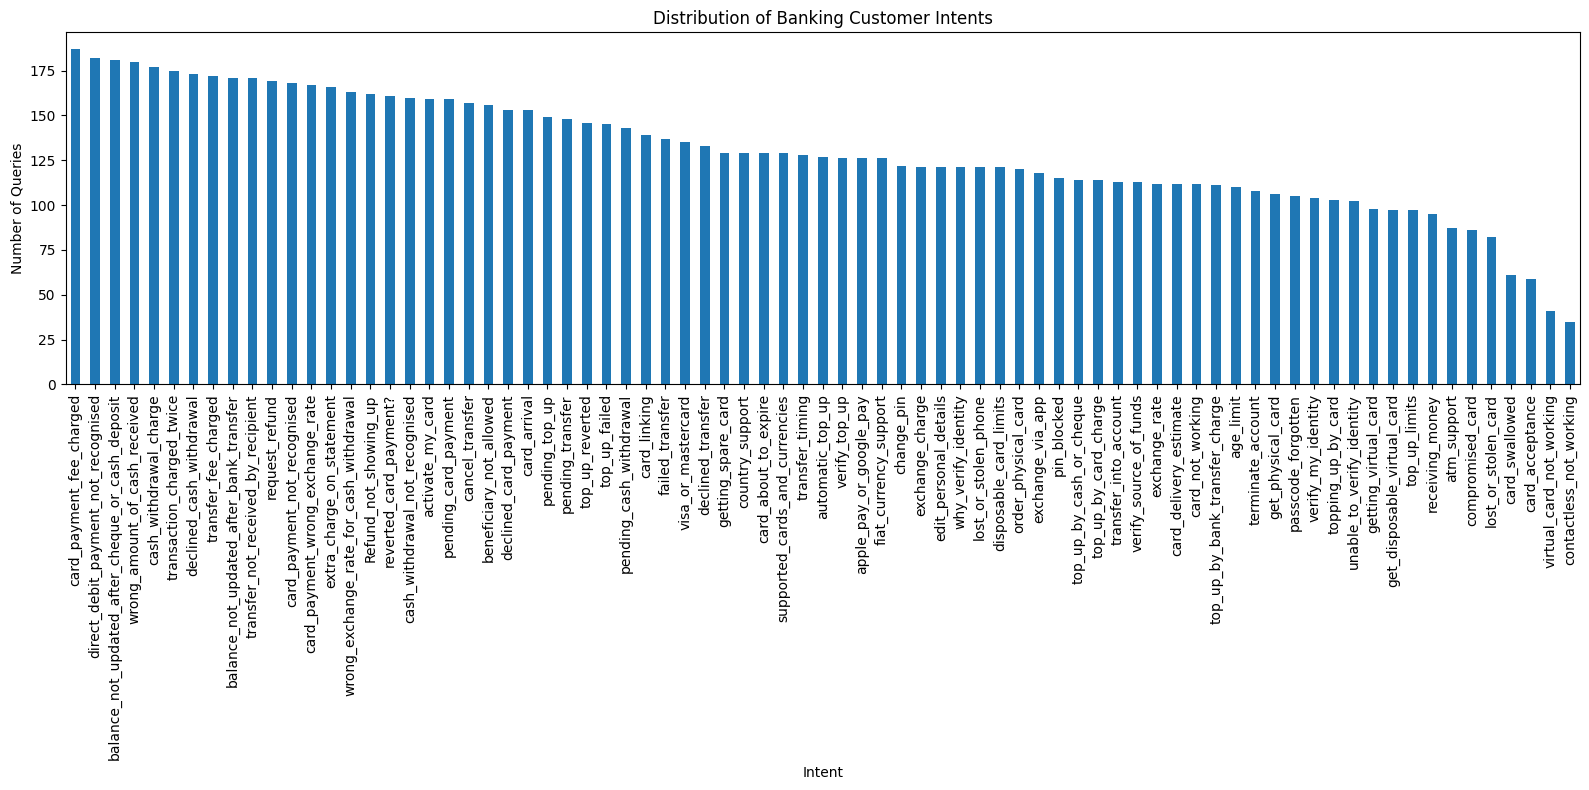

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

intent_counts.plot(kind="bar")

plt.title("Distribution of Banking Customer Intents")
plt.xlabel("Intent")
plt.ylabel("Number of Queries")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### 2.7 Most Frequent and Least Frequent Intents

We identify the most and least represented banking intents to better
understand the distribution of customer queries in the dataset.

In [21]:
print("Top 10 most frequent intents:")
print(intent_counts.head(10))

Top 10 most frequent intents:
category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
transaction_charged_twice                           175
declined_cash_withdrawal                            173
transfer_fee_charged                                172
balance_not_updated_after_bank_transfer             171
transfer_not_received_by_recipient                  171
Name: count, dtype: int64


In [22]:
print("\nTop 10 least frequent intents:")
print(intent_counts.tail(10))


Top 10 least frequent intents:
category
get_disposable_virtual_card    97
top_up_limits                  97
receiving_money                95
atm_support                    87
compromised_card               86
lost_or_stolen_card            82
card_swallowed                 61
card_acceptance                59
virtual_card_not_working       41
contactless_not_working        35
Name: count, dtype: int64


### 2.8 Sample Customer Queries by Intent

Examining real examples from different intent categories helps us
understand the linguistic patterns and semantic differences between
banking customer-service intents.

In [23]:
for intent in intents[:10]:
    print("\n" + "=" * 60)
    print("INTENT:", intent)
    print("=" * 60)

    samples = train_df[
        train_df["category"] == intent
    ]["text"].sample(
        min(3, len(train_df[train_df["category"] == intent])),
        random_state=42
    )

    for text in samples:
        print("-", text)


INTENT: Refund_not_showing_up
- I made a big purchase that I regretted and cancelled, the merchant said that my refund was submitted. Can you confirm to me that all of my money was truly returned to me?
- I am still waiting to find out the status of my refund. I have made previous attempts to find out what the status is to no avail. Will you please look into this for me?
- As advised by you, i requested seller to refund my money. A week has passed but i haven't got any update from seller. Please track the refund with the seller.

INTENT: activate_my_card
- I need to activate my card, how is that done?
- My new card has arrived, what's the activation procedure?
- I need to do a card activation.

INTENT: age_limit
- As my kids get older are they able to get set up with their own accounts?
- How old does my daughter have to be to open an account?
- How old do I need to be?

INTENT: apple_pay_or_google_pay
- I can't get google pay to work right.
- I got my American Express in Apple Pay, w

### 2.9 Customer Query Length Analysis

The length of customer queries is analyzed to understand how much
text the intent classification model will typically process.

In [24]:
train_df["text_length"] = train_df["text"].str.len()

train_df["word_count"] = train_df["text"].str.split().str.len()

train_df[["text", "text_length", "word_count"]].head(10)

,text,text_length,word_count
0,I am still waiting on my card?,30,7
1,What can I do if my card still hasn't arrived ...,60,13
2,I have been waiting over a week. Is the card s...,58,12
3,Can I track my card while it is in the process...,59,13
4,"How do I know if I will get my card, or if it ...",54,15
5,When did you send me my new card?,33,8
6,Do you have info about the card on delivery?,44,9
7,What do I do if I still have not received my n...,54,13
8,Does the package with my card have tracking?,44,8
9,I ordered my card but it still isn't here,41,9


In [25]:
print("Average character length:",
      train_df["text_length"].mean())

print("Average word count:",
      train_df["word_count"].mean())

print("Maximum word count:",
      train_df["word_count"].max())

print("Minimum word count:",
      train_df["word_count"].min())

Average character length: 59.47375787263821
Average word count: 11.949415175447365
Maximum word count: 79
Minimum word count: 2


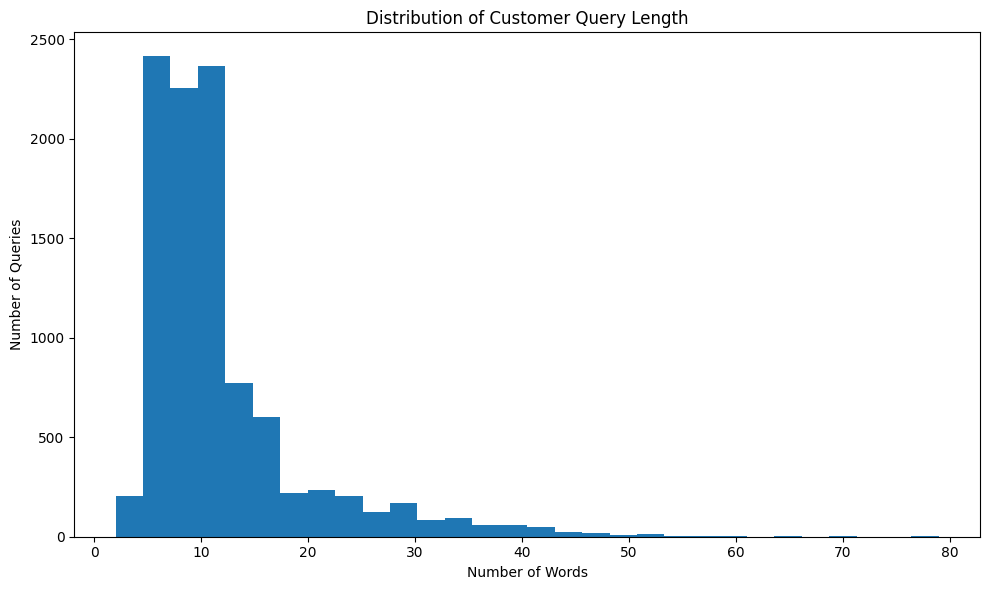

In [26]:
plt.figure(figsize=(10, 6))

plt.hist(train_df["word_count"], bins=30)

plt.title("Distribution of Customer Query Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Queries")

plt.tight_layout()
plt.show()

### 2.10 EDA Summary

The exploratory analysis provides the following insights:

- BANKING77 contains 10,003 training examples and 3,080 testing examples.
- The dataset contains 77 fine-grained banking customer-service intents.
- Customer queries are stored as natural-language text.
- The intent/category column serves as the target variable.
- Missing-value and duplicate analysis was performed.
- Intent distribution was examined to identify potential class imbalance.
- Customer query lengths were analyzed to understand the characteristics
  of the textual data.

These findings provide the foundation for the next stage: text
preprocessing and intent classification.

## 3. Data Preprocessing

Data preprocessing is performed to prepare the raw customer queries
for machine learning. The objective is to transform the textual data
into a clean and consistent representation while preserving the
information required for intent classification.

The preprocessing pipeline includes text normalization, target
preparation, and separation of training and testing data.

### 3.1 Creating a Working Copy

A separate working copy of the dataset is created so that preprocessing
operations do not modify the original dataset.

In [28]:
train_processed = train_df.copy()
test_processed = test_df.copy()

print("Training data shape:", train_processed.shape)
print("Testing data shape:", test_processed.shape)

Training data shape: (10003, 4)
Testing data shape: (3080, 2)


### 3.2 Inspecting Raw Customer Queries

Before applying text preprocessing, we inspect the raw customer queries
to understand their current format.

In [29]:
for i in range(5):
    print(f"{i+1}. {train_processed['text'].iloc[i]}")

1. I am still waiting on my card?
2. What can I do if my card still hasn't arrived after 2 weeks?
3. I have been waiting over a week. Is the card still coming?
4. Can I track my card while it is in the process of delivery?
5. How do I know if I will get my card, or if it is lost?


### 3.3 Text Normalization

Text normalization reduces unnecessary variations in customer queries.
For the baseline model, text is converted to lowercase and redundant
whitespace is removed.

Aggressive preprocessing such as removing stopwords or stemming is
avoided at this stage because important banking terms may carry useful
semantic information.

In [30]:
import re

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [31]:
train_processed["clean_text"] = train_processed["text"].apply(normalize_text)
test_processed["clean_text"] = test_processed["text"].apply(normalize_text)

In [32]:
train_processed[["text", "clean_text"]].head(10)

,text,clean_text
0,I am still waiting on my card?,i am still waiting on my card?
1,What can I do if my card still hasn't arrived ...,what can i do if my card still hasn't arrived ...
2,I have been waiting over a week. Is the card s...,i have been waiting over a week. is the card s...
3,Can I track my card while it is in the process...,can i track my card while it is in the process...
4,"How do I know if I will get my card, or if it ...","how do i know if i will get my card, or if it ..."
5,When did you send me my new card?,when did you send me my new card?
6,Do you have info about the card on delivery?,do you have info about the card on delivery?
7,What do I do if I still have not received my n...,what do i do if i still have not received my n...
8,Does the package with my card have tracking?,does the package with my card have tracking?
9,I ordered my card but it still isn't here,i ordered my card but it still isn't here


### 3.4 Comparing Raw and Normalized Text

The original and normalized versions of customer queries are compared
to verify that preprocessing has been applied correctly.

In [33]:
for i in range(5):
    print("Original :", train_processed["text"].iloc[i])
    print("Processed:", train_processed["clean_text"].iloc[i])
    print("-" * 80)

Original : I am still waiting on my card?
Processed: i am still waiting on my card?
--------------------------------------------------------------------------------
Original : What can I do if my card still hasn't arrived after 2 weeks?
Processed: what can i do if my card still hasn't arrived after 2 weeks?
--------------------------------------------------------------------------------
Original : I have been waiting over a week. Is the card still coming?
Processed: i have been waiting over a week. is the card still coming?
--------------------------------------------------------------------------------
Original : Can I track my card while it is in the process of delivery?
Processed: can i track my card while it is in the process of delivery?
--------------------------------------------------------------------------------
Original : How do I know if I will get my card, or if it is lost?
Processed: how do i know if i will get my card, or if it is lost?
----------------------------------

### 3.5 Preparing Features and Target Variables

The customer query is used as the input feature, while the banking
intent category is used as the target variable.

The objective of the classification model is to learn the relationship
between customer queries and their corresponding banking intents.

In [34]:
X_train = train_processed["clean_text"]
y_train = train_processed["category"]

X_test = test_processed["clean_text"]
y_test = test_processed["category"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (10003,)
y_train: (10003,)
X_test : (3080,)
y_test : (3080,)


### 3.6 Verifying Target Classes

The target variable is checked to ensure that all 77 banking intents
are available for classification.

In [35]:
print("Number of training classes:", y_train.nunique())
print("Number of testing classes:", y_test.nunique())

Number of training classes: 77
Number of testing classes: 77


### 3.7 Preprocessing Summary

The following preprocessing steps were completed:

- Created independent working copies of the training and testing data.
- Normalized customer queries by converting text to lowercase.
- Removed redundant whitespace.
- Preserved important banking-related terminology.
- Separated customer queries from their corresponding intent labels.
- Prepared training and testing features for machine learning.

The processed data is now ready for feature extraction and model training.

## 4. Intent Classification

### 4.1 TF-IDF Feature Extraction

Machine learning algorithms cannot directly process raw text.
Therefore, customer queries must first be converted into numerical
features.

TF-IDF (Term Frequency-Inverse Document Frequency) represents each
customer query as a numerical vector based on the importance of words
and word combinations within the dataset.

We use both unigrams and bigrams to capture individual words as well
as short phrases.

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
tfidf = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    max_features=30000
)

### 4.2 Fitting the TF-IDF Vectorizer

The TF-IDF vectorizer is fitted exclusively on the training data.
The learned vocabulary and statistical information are then used to
transform both training and testing queries.

This prevents information from the test set from leaking into the
training process.

In [39]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [40]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (10003, 23608)
Testing TF-IDF shape: (3080, 23608)


### 4.3 Inspecting TF-IDF Vocabulary

The learned vocabulary is inspected to understand the textual features
generated from the banking customer queries.

In [43]:
feature_names = tfidf.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("\nFirst 50 features:")
print(feature_names[:50])

Number of TF-IDF features: 23608

First 50 features:
['00' '00 has' '00 in' '000' '000 but' '000 from' '000 to' '10' '10 000'
 '10 atm' '10 minutes' '10 pounds' '10 still' '10 the' '10 transactions'
 '10 why' '100' '100 all' '100 but' '100 from' '100 into' '100 it'
 '100 only' '100 out' '100 pounds' '100 that' '13' '13 is' '16' '16 and'
 '18' '18 and' '18 or' '18 to' '18 years' '1818' '1818 transfering' '1l'
 '1l appears' '1l do' '1l in' '20' '20 00' '20 after' '20 but' '20 came'
 '20 instead' '20 now' '20 of' '20 what']


### 4.4 Inspecting a Customer Query as a TF-IDF Vector

A customer query is represented as a sparse numerical vector after
TF-IDF transformation. Most features have a value of zero because a
single query contains only a small subset of the complete vocabulary.

In [44]:
sample_query = X_train.iloc[0]

print("Original query:")
print(sample_query)

print("\nTF-IDF vector shape:")
print(X_train_tfidf[0].shape)

Original query:
i am still waiting on my card?

TF-IDF vector shape:
(1, 23608)


In [45]:
non_zero_features = X_train_tfidf[0].nonzero()[1]

for index in non_zero_features:
    print(feature_names[index], "->", X_train_tfidf[0, index])

am -> 0.25045820055601165
still -> 0.2666186934917499
waiting -> 0.3563164334513188
on -> 0.2126467911172315
my -> 0.10310218897065936
card -> 0.1439997029450656
am still -> 0.4227165496994996
still waiting -> 0.4086243549732222
waiting on -> 0.4673966018703363
on my -> 0.2532247916519013
my card -> 0.1854551274622703


### 4.5 Training the Logistic Regression Classifier

Logistic Regression is used as the baseline classification algorithm.
It is computationally efficient, interpretable, and performs well for
high-dimensional sparse text features such as TF-IDF vectors.

The model learns to map TF-IDF representations of customer queries to
one of the 77 banking intent categories.

In [46]:
from sklearn.linear_model import LogisticRegression

intent_classifier = LogisticRegression(
    max_iter=1000,
    C=1.0
)

In [47]:
intent_classifier.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 4.6 Generating Intent Predictions

The trained classifier is used to predict the banking intent of
customer queries in the unseen test dataset.

In [48]:
y_pred = intent_classifier.predict(X_test_tfidf)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
['card_linking' 'card_arrival' 'transfer_not_received_by_recipient'
 'card_arrival' 'transfer_not_received_by_recipient'
 'card_delivery_estimate' 'card_arrival' 'card_arrival' 'card_arrival'
 'card_arrival' 'card_arrival' 'card_delivery_estimate' 'card_arrival'
 'card_arrival' 'card_arrival' 'card_arrival' 'card_arrival'
 'card_arrival' 'card_arrival' 'card_arrival']


In [49]:
comparison = pd.DataFrame({
    "Customer Query": X_test.iloc[:20].values,
    "Actual Intent": y_test.iloc[:20].values,
    "Predicted Intent": y_pred[:20]
})

comparison

,Customer Query,Actual Intent,Predicted Intent
0,how do i locate my card?,card_arrival,card_linking
1,"i still have not received my new card, i order...",card_arrival,card_arrival
2,i ordered a card but it has not arrived. help ...,card_arrival,transfer_not_received_by_recipient
3,is there a way to know when my card will arrive?,card_arrival,card_arrival
4,my card has not arrived yet.,card_arrival,transfer_not_received_by_recipient
5,when will i get my card?,card_arrival,card_delivery_estimate
6,do you know if there is a tracking number for ...,card_arrival,card_arrival
7,i have not received my card,card_arrival,card_arrival
8,still waiting on that card,card_arrival,card_arrival
9,is it normal to have to wait over a week for m...,card_arrival,card_arrival


### 4.7 Model Accuracy

Accuracy is calculated to measure the percentage of customer queries
for which the model correctly predicts the banking intent.

In [50]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.8545
Accuracy: 85.45%


### 4.8 Classification Report

A detailed classification report is generated to evaluate the model
across all 77 banking intents using precision, recall, and F1-score.

- Precision: How many predictions for an intent were actually correct.
- Recall: How many examples belonging to an intent were correctly found.
- F1-score: Harmonic mean of precision and recall.

In [51]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred
)

print(report)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.84      0.95      0.89        40
                                activate_my_card       1.00      0.93      0.96        40
                                       age_limit       1.00      1.00      1.00        40
                         apple_pay_or_google_pay       0.98      1.00      0.99        40
                                     atm_support       0.86      0.80      0.83        40
                                automatic_top_up       1.00      0.90      0.95        40
         balance_not_updated_after_bank_transfer       0.64      0.80      0.71        40
balance_not_updated_after_cheque_or_cash_deposit       0.84      0.93      0.88        40
                         beneficiary_not_allowed       0.90      0.88      0.89        40
                                 cancel_transfer       0.88      0.95      0.92        40
         

### 4.9 Saving the Baseline Model

The trained TF-IDF vectorizer and Logistic Regression classifier are
saved so that they can be reused later without retraining the model.

In [54]:
import os

os.makedirs("models", exist_ok=True)

print("models folder created successfully!")

models folder created successfully!


In [56]:
import joblib

joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")
joblib.dump(intent_classifier, "models/intent_classifier.pkl")

print("TF-IDF vectorizer saved successfully.")
print("Intent classifier saved successfully.")

TF-IDF vectorizer saved successfully.
Intent classifier saved successfully.


In [57]:
print(os.listdir("models"))

['intent_classifier.pkl', 'tfidf_vectorizer.pkl']


### 4.11 Baseline Model Performance Analysis

- The TF-IDF + Logistic Regression baseline achieved an accuracy of
85.45% on the 3,080-query test set.

- The model achieved a macro-average F1-score of 0.85 across the
77 banking intent categories, indicating reasonably consistent
performance across the intent classes.

- Several intents achieved near-perfect performance, including
`age_limit`, `passcode_forgotten`, and `verify_top_up`.

- However, performance was weaker for semantically similar categories
such as `virtual_card_not_working`, `card_not_working`,
`pending_transfer`, and `balance_not_updated_after_bank_transfer`.

- These errors highlight the limitations of traditional TF-IDF-based
text representation, which relies heavily on word and phrase
frequency rather than deeper semantic understanding.

- The baseline therefore provides a strong reference point for evaluating
more advanced semantic and retrieval-based approaches later in the
project.

## 5. Error Analysis

Error analysis is performed to understand the types of customer queries
that are incorrectly classified by the baseline intent classifier.

Rather than evaluating the model only using aggregate metrics, we
inspect individual prediction errors to identify patterns, ambiguous
intents, and limitations of the TF-IDF representation.

This analysis will help guide the development of more advanced
semantic and retrieval-based components later in the project.

### 5.1 Identifying Misclassified Queries

In [58]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "actual_intent": y_test.values,
    "predicted_intent": y_pred
})

misclassified = error_df[
    error_df["actual_intent"] != error_df["predicted_intent"]
].copy()

print("Total test queries:", len(error_df))
print(
    "Correct predictions:",
    (error_df["actual_intent"] == error_df["predicted_intent"]).sum()
)
print("Misclassified queries:", len(misclassified))

Total test queries: 3080
Correct predictions: 2632
Misclassified queries: 448


In [59]:
error_df["actual_intent"] != error_df["predicted_intent"]

0        True
1       False
2        True
3       False
4        True
        ...  
3075    False
3076    False
3077    False
3078    False
3079    False
Length: 3080, dtype: bool

In [60]:
misclassified.head(20)

,text,actual_intent,predicted_intent
0,how do i locate my card?,card_arrival,card_linking
2,i ordered a card but it has not arrived. help ...,card_arrival,transfer_not_received_by_recipient
4,my card has not arrived yet.,card_arrival,transfer_not_received_by_recipient
5,when will i get my card?,card_arrival,card_delivery_estimate
11,how long does a card delivery take?,card_arrival,card_delivery_estimate
32,how do i know when my card will arrive?,card_arrival,card_delivery_estimate
36,i'm starting to think my card is lost because ...,card_arrival,lost_or_stolen_card
79,can i link another card to my account?,card_linking,getting_spare_card
93,is it a good time to exchange?,exchange_rate,exchange_via_app
106,the exchange rate would be?,exchange_rate,card_payment_wrong_exchange_rate


### 5.2 Most Confused Intent Pairs

In [61]:
from collections import Counter

confusions = Counter(
    zip(
        misclassified["actual_intent"],
        misclassified["predicted_intent"]
    )
)

print("Top 15 confusion pairs:\n")

for (actual, predicted), count in confusions.most_common(15):
    print(f"{actual} → {predicted}: {count}")

Top 15 confusion pairs:

virtual_card_not_working → getting_virtual_card: 13
virtual_card_not_working → get_disposable_virtual_card: 9
card_acceptance → card_not_working: 8
why_verify_identity → verify_my_identity: 6
unable_to_verify_identity → verify_my_identity: 6
request_refund → Refund_not_showing_up: 6
pin_blocked → get_physical_card: 4
contactless_not_working → card_not_working: 4
top_up_reverted → top_up_failed: 4
card_payment_not_recognised → extra_charge_on_statement: 4
disposable_card_limits → get_disposable_virtual_card: 4
pending_transfer → pending_card_payment: 4
pending_transfer → transfer_timing: 4
card_swallowed → declined_cash_withdrawal: 4
top_up_by_cash_or_cheque → balance_not_updated_after_cheque_or_cash_deposit: 4


### 5.2 Most Confused Intent Pairs

The confusion analysis shows that the baseline TF-IDF + Logistic Regression
model mainly struggles with banking intents that are semantically similar.

The most frequent confusion was between `virtual_card_not_working` and
`getting_virtual_card`, followed by `virtual_card_not_working` and
`get_disposable_virtual_card`.

Other notable confusions include `card_acceptance` being predicted as
`card_not_working`, and `why_verify_identity` or `unable_to_verify_identity`
being predicted as `verify_my_identity`.

These errors indicate that the model can identify the general topic of a
customer query but sometimes fails to distinguish between closely related
intent categories.

This is a limitation of the TF-IDF representation because it primarily
captures word and phrase frequency rather than the deeper semantic meaning
of the complete customer query.

The confusion analysis therefore provides motivation for introducing
semantic text representations in later stages of the project.

### 5.3 Prediction Confidence Analysis

In [62]:
import numpy as np

# Get probability for every intent
prediction_probabilities = intent_classifier.predict_proba(X_test_tfidf)

# Get the highest probability for each prediction
prediction_confidence = prediction_probabilities.max(axis=1)

# Add confidence and correctness information
error_df["confidence"] = prediction_confidence
error_df["correct"] = (
    error_df["actual_intent"] == error_df["predicted_intent"]
)

print("Average confidence:",
      round(prediction_confidence.mean(), 4))

print(
    "Average confidence for correct predictions:",
    round(
        error_df.loc[error_df["correct"], "confidence"].mean(),
        4
    )
)

print(
    "Average confidence for incorrect predictions:",
    round(
        error_df.loc[~error_df["correct"], "confidence"].mean(),
        4
    )
)

Average confidence: 0.4014
Average confidence for correct predictions: 0.4392
Average confidence for incorrect predictions: 0.1799


### 5.4 High-Confidence Misclassifications

In [63]:
high_confidence_errors = (
    error_df[~error_df["correct"]]
    .sort_values("confidence", ascending=False)
)

high_confidence_errors[
    [
        "text",
        "actual_intent",
        "predicted_intent",
        "confidence"
    ]
].head(20)

,text,actual_intent,predicted_intent,confidence
2711,my transfer is pending.,balance_not_updated_after_bank_transfer,pending_transfer,0.883971
2606,i would like a temporary virtual card,get_disposable_virtual_card,getting_virtual_card,0.842270
2637,how many transactions can i make with a dispos...,get_disposable_virtual_card,disposable_card_limits,0.789870
2761,whats your exchange rate,exchange_charge,exchange_rate,0.711368
2503,can i have a non virtual card?,order_physical_card,getting_virtual_card,0.657694
271,can i exchange currencies?,fiat_currency_support,exchange_via_app,0.642593
1193,do i need to verify my identity?,why_verify_identity,verify_my_identity,0.632822
1752,i can't transfer money from my account.,declined_transfer,transfer_into_account,0.597419
1220,i can't verify my identity.,unable_to_verify_identity,verify_my_identity,0.529987
2638,what are disposable cards?,get_disposable_virtual_card,disposable_card_limits,0.521145


### 5.5 Baseline Model Limitations

- The error analysis reveals several limitations of the TF-IDF + Logistic
Regression baseline.

- The model performs well when different intents contain clearly
distinguishable vocabulary. However, it struggles when multiple intents
share similar words and belong to the same banking domain.

- The most frequent errors occur among semantically related categories,
including virtual-card intents, identity-verification intents,
transfer-related intents, and exchange-related intents.

- High-confidence errors further demonstrate that lexical similarity can
sometimes cause the model to make incorrect predictions with relatively
high confidence.

- These findings indicate that improving the system requires a richer
representation of semantic meaning rather than relying only on word and
phrase frequency.

- The baseline model therefore serves as an important benchmark and provides
a clear foundation for introducing semantic embeddings and retrieval-based
methods in later stages.

## 6. Semantic Intent Classification

The baseline TF-IDF model represents customer queries mainly through
word and phrase frequency. While this approach achieved 85.45% accuracy,
the error analysis showed that it struggles with semantically similar
banking intents.

To address this limitation, we introduce semantic embeddings.

A sentence embedding represents the meaning of an entire customer query
as a dense numerical vector. Queries with similar meanings are expected
to have similar vector representations, even when they use different
words.

These embeddings will allow us to build a stronger intent classification
system and compare its performance against the TF-IDF baseline.

In [64]:
!pip install -q sentence-transformers


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 6.1 Loading the Sentence Embedding Model

We use a pre-trained Sentence Transformer to convert customer queries
into dense semantic vectors.

The model has already learned general language relationships from large
amounts of text, allowing it to represent the meaning of a complete
sentence rather than relying only on individual word frequencies.

In [65]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 6.2 Generating Sentence Embeddings

The pre-trained embedding model is used to convert the cleaned training
and testing queries into dense numerical vectors.

The same embedding model is used for both datasets to ensure that the
resulting vectors are represented in the same semantic space.

In [66]:
X_train_embeddings = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_test_embeddings = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

### 6.3 Inspecting Embedding Dimensions

Each customer query is represented by a fixed-length dense vector.
We inspect the resulting dimensions to verify that the embeddings were
generated correctly.

In [67]:
print("Training embeddings shape:", X_train_embeddings.shape)
print("Testing embeddings shape:", X_test_embeddings.shape)

Training embeddings shape: (10003, 384)
Testing embeddings shape: (3080, 384)


### 6.4 Training a Classifier on Semantic Embeddings

The generated sentence embeddings capture semantic information about each
customer query.

We now train a Logistic Regression classifier using these embeddings as
input features.

This allows us to compare the semantic representation with the earlier
TF-IDF representation while keeping the classification algorithm the same.

Using the same classifier makes the comparison more meaningful because
the main change is the text representation rather than the classification
algorithm.

In [68]:
from sklearn.linear_model import LogisticRegression

embedding_classifier = LogisticRegression(
    max_iter=1000,
    C=1.0
)

embedding_classifier.fit(
    X_train_embeddings,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 6.5 Generating Intent Predictions

The trained classifier is used to predict the banking intent of each
customer query in the test set.

These predictions will be evaluated using the same metrics used for the
TF-IDF baseline.

In [69]:
y_pred_embeddings = embedding_classifier.predict(
    X_test_embeddings
)

print("Sample predictions:")
print(y_pred_embeddings[:10])

Sample predictions:
['card_linking' 'card_arrival' 'card_arrival' 'card_arrival'
 'card_arrival' 'card_delivery_estimate' 'card_arrival' 'card_arrival'
 'card_arrival' 'card_arrival']


### 6.6 Semantic Model Accuracy

We evaluate the semantic intent classifier using accuracy and compare it
with the 85.45% accuracy achieved by the TF-IDF + Logistic Regression
baseline.

In [70]:
from sklearn.metrics import accuracy_score

embedding_accuracy = accuracy_score(
    y_test,
    y_pred_embeddings
)

print(
    "Semantic Embedding Model Accuracy:",
    round(embedding_accuracy, 4)
)

print(
    "Semantic Embedding Model Accuracy (%):",
    round(embedding_accuracy * 100, 2),
    "%"
)

Semantic Embedding Model Accuracy: 0.9081
Semantic Embedding Model Accuracy (%): 90.81 %


### 6.7 Semantic Model Classification Report

The classification report provides precision, recall, and F1-score for
each of the 77 banking intent categories.

This allows us to determine whether semantic embeddings improve the
performance of the difficult intent categories identified during error
analysis.

In [71]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_embeddings
    )
)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       1.00      0.88      0.93        40
                                activate_my_card       1.00      0.90      0.95        40
                                       age_limit       0.98      1.00      0.99        40
                         apple_pay_or_google_pay       0.98      1.00      0.99        40
                                     atm_support       1.00      0.95      0.97        40
                                automatic_top_up       1.00      0.88      0.93        40
         balance_not_updated_after_bank_transfer       0.76      0.78      0.77        40
balance_not_updated_after_cheque_or_cash_deposit       0.93      0.95      0.94        40
                         beneficiary_not_allowed       0.87      0.82      0.85        40
                                 cancel_transfer       0.95      1.00      0.98        40
         

### 6.8 TF-IDF vs Semantic Embedding Model

The two models use the same Logistic Regression classifier but different
text representations.

This comparison helps determine whether semantic embeddings provide a
meaningful improvement over traditional TF-IDF features.

In [72]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "Sentence Embeddings + Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        embedding_accuracy
    ]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

comparison

,Model,Accuracy,Accuracy (%)
0,TF-IDF + Logistic Regression,0.854545,85.454545
1,Sentence Embeddings + Logistic Regression,0.908117,90.811688


### 6.9 Semantic Model Performance Analysis

The Sentence Embeddings + Logistic Regression model achieved an accuracy
of 90.81% on the test set, compared with 85.45% for the TF-IDF +
Logistic Regression baseline.

This represents an improvement of approximately 5.36 percentage points.

The improvement indicates that semantic embeddings provide a richer
representation of customer queries than traditional TF-IDF features.

In particular, sentence embeddings can capture contextual and semantic
relationships between words and phrases, which is useful for distinguishing
between closely related banking intents.

The result validates the decision to move beyond a purely lexical
representation and provides a stronger foundation for the subsequent
retrieval and response-generation components of the system.

### 6.10 Comparing Difficult Intent Categories

The error analysis of the TF-IDF baseline identified several difficult
intent categories, particularly those involving semantically similar
customer queries.

We compare the F1-scores of these categories between the TF-IDF and
semantic embedding models to determine whether the improved overall
accuracy is also reflected in the difficult cases.

In [73]:
from sklearn.metrics import classification_report

tfidf_report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

embedding_report = classification_report(
    y_test,
    y_pred_embeddings,
    output_dict=True
)

difficult_intents = [
    "virtual_card_not_working",
    "card_acceptance",
    "why_verify_identity",
    "unable_to_verify_identity",
    "pending_transfer",
    "exchange_rate",
    "get_disposable_virtual_card"
]

comparison_df = pd.DataFrame({
    "Intent": difficult_intents,
    "TF-IDF F1": [
        tfidf_report[intent]["f1-score"]
        for intent in difficult_intents
    ],
    "Embedding F1": [
        embedding_report[intent]["f1-score"]
        for intent in difficult_intents
    ]
})

comparison_df["Improvement"] = (
    comparison_df["Embedding F1"] -
    comparison_df["TF-IDF F1"]
)

comparison_df

,Intent,TF-IDF F1,Embedding F1,Improvement
0,virtual_card_not_working,0.461538,0.888889,0.427350
1,card_acceptance,0.742857,0.894737,0.151880
2,why_verify_identity,0.820513,0.900000,0.079487
3,unable_to_verify_identity,0.831169,0.936709,0.105540
4,pending_transfer,0.695652,0.764706,0.069054
5,exchange_rate,0.913580,0.951220,0.037639
6,get_disposable_virtual_card,0.722892,0.868421,0.145529


### 6.11 Analysis of Difficult Intent Categories

The semantic embedding model substantially improves several of the
challenging intent categories identified during the baseline error
analysis.

A particularly significant improvement is observed for
`virtual_card_not_working`, where the F1-score increased from 0.46 with
the TF-IDF model to 0.89 with semantic embeddings.

The `card_acceptance` intent also improved from a baseline F1-score of
0.74 to 0.89, while `get_disposable_virtual_card` improved to 0.87.

These improvements demonstrate that semantic embeddings are better suited
to distinguishing between banking queries that share similar vocabulary
but express different meanings.

Some categories, such as `pending_transfer`, remain relatively difficult,
with an F1-score of 0.76. This indicates that semantic embeddings improve
the representation of customer queries but do not completely eliminate
ambiguity between closely related banking intents.

Overall, the results demonstrate that semantic embeddings provide a
substantial improvement over the TF-IDF baseline.

### 6.12 Baseline vs Semantic Model

The final comparison summarizes the performance improvement achieved by
replacing TF-IDF features with semantic sentence embeddings while keeping
the Logistic Regression classifier unchanged.

In [74]:
final_comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "Sentence Embeddings + Logistic Regression"
    ],
    "Accuracy (%)": [
        accuracy * 100,
        embedding_accuracy * 100
    ]
})

final_comparison["Improvement (percentage points)"] = [
    0,
    (embedding_accuracy - accuracy) * 100
]

final_comparison

,Model,Accuracy (%),Improvement (percentage points)
0,TF-IDF + Logistic Regression,85.454545,0.000000
1,Sentence Embeddings + Logistic Regression,90.811688,5.357143


### 6.13 Section Summary

- The semantic intent classification stage improved the test accuracy from
85.45% to 90.81%, representing an improvement of approximately 5.36
percentage points.

- The comparison also showed substantial improvements in several
semantically challenging intent categories.

- The results demonstrate that sentence embeddings provide a stronger
representation of customer queries than traditional TF-IDF features.

- However, approximately 9.19% of test queries are still misclassified.
Some closely related banking intents remain difficult to distinguish.

- Therefore, the semantic classifier will serve as the intent-understanding
component of the larger banking support system, while retrieval and
grounded response generation will be introduced in the next stages.

## 7. Banking Knowledge Base & RAG Preparation

A customer-support system needs access to reliable banking information
before it can generate useful responses.

For this project, a fictional banking institution named NovaBank is used
to create a controlled knowledge base.

The knowledge base contains information about common banking operations,
including cards, transfers, payments, account verification, cash
withdrawals, refunds, and top-ups.

This information will later be converted into semantic embeddings and
stored in a vector database for retrieval.

### 7.1 Designing the NovaBank Knowledge Base

The knowledge base is organized into small, self-contained documents.
Each document contains information about a specific banking topic.

Keeping documents relatively focused improves retrieval because the
retrieval system can return information that is directly relevant to the
customer's question.

In [75]:
novabank_knowledge = [
    {
        "title": "Card Not Working",
        "category": "cards",
        "content": """
        If a NovaBank card is not working, first check whether the card
        is activated and whether it has expired. Customers should also
        verify that the card has not been temporarily frozen in the
        NovaBank mobile application. If the problem continues, the
        customer can contact NovaBank support for assistance.
        """
    },

    {
        "title": "Card Activation",
        "category": "cards",
        "content": """
        NovaBank customers can activate a new physical card through the
        NovaBank mobile application. The customer should follow the card
        activation instructions displayed in the app. A card must be
        activated before it can normally be used for payments.
        """
    },

    {
        "title": "Lost or Stolen Card",
        "category": "cards",
        "content": """
        If a NovaBank card is lost or stolen, the customer should
        immediately freeze the card using the NovaBank mobile application.
        The customer can then contact NovaBank support to request further
        assistance or a replacement card.
        """
    },

    {
        "title": "Virtual Cards",
        "category": "cards",
        "content": """
        NovaBank provides virtual cards for eligible customers. A virtual
        card can be accessed through the NovaBank mobile application and
        can be used for supported online transactions.
        """
    },

    {
        "title": "Disposable Virtual Cards",
        "category": "cards",
        "content": """
        NovaBank disposable virtual cards are designed for supported
        online transactions where additional card-number protection is
        useful. Availability and transaction limits may depend on the
        customer's account and current NovaBank policies.
        """
    },

    {
        "title": "Bank Transfers",
        "category": "transfers",
        "content": """
        NovaBank customers can make bank transfers through supported
        transfer methods in the mobile application. Transfer processing
        times may vary depending on the destination bank and transfer
        method. Customers should check the transfer status in the app
        before contacting support.
        """
    },

    {
        "title": "Pending Transfers",
        "category": "transfers",
        "content": """
        A bank transfer may remain pending while NovaBank or the
        destination banking network processes the transaction. Customers
        should check the transfer status in the application. If the
        transfer remains pending beyond the expected processing period,
        the customer should contact NovaBank support.
        """
    },

    {
        "title": "Transfer Not Received",
        "category": "transfers",
        "content": """
        If a completed NovaBank transfer has not been received by the
        recipient, the customer should first verify the recipient details
        and transfer status. If the transaction shows as completed but
        the recipient has not received the funds, NovaBank support can
        investigate the transaction.
        """
    },

    {
        "title": "Card Payments",
        "category": "payments",
        "content": """
        NovaBank card payments may be declined because of insufficient
        funds, card restrictions, merchant restrictions, security checks,
        or other transaction conditions. Customers should check the
        transaction status in the NovaBank application.
        """
    },

    {
        "title": "Unrecognized Card Payment",
        "category": "payments",
        "content": """
        If a NovaBank customer does not recognize a card payment, they
        should review the transaction details and immediately freeze the
        card if they suspect unauthorized activity. The customer should
        contact NovaBank support to report a potentially unauthorized
        transaction.
        """
    },

    {
        "title": "Refunds",
        "category": "refunds",
        "content": """
        Refund processing times can vary depending on the merchant and
        payment method. Customers who are waiting for a refund should
        first verify the refund status with the merchant. If the expected
        refund does not appear after the applicable processing period,
        NovaBank support can assist with the transaction.
        """
    },

    {
        "title": "Identity Verification",
        "category": "verification",
        "content": """
        NovaBank may require customers to verify their identity for
        account security, regulatory requirements, and fraud prevention.
        Customers should follow the identity verification instructions
        provided in the NovaBank application.
        """
    },

    {
        "title": "Unable to Verify Identity",
        "category": "verification",
        "content": """
        If identity verification fails, customers should ensure that
        submitted information and documents are clear, valid, and match
        their account details. If verification continues to fail, the
        customer should contact NovaBank support.
        """
    },

    {
        "title": "Top Up by Card",
        "category": "top_up",
        "content": """
        Customers can add money to their NovaBank account using supported
        payment cards through the mobile application. The available top-up
        methods and limits may depend on the account and current NovaBank
        policies.
        """
    },

    {
        "title": "Failed Top Up",
        "category": "top_up",
        "content": """
        If a NovaBank top-up fails, customers should verify that the
        payment card is supported, the card details are correct, and the
        account has sufficient funds. If the issue continues, the
        customer should contact NovaBank support.
        """
    },

    {
        "title": "Cash Withdrawal",
        "category": "cash_withdrawal",
        "content": """
        NovaBank customers can withdraw cash using supported cards and
        ATMs. Availability, fees, and withdrawal limits may depend on the
        account, card, ATM, and applicable NovaBank policies.
        """
    },

    {
        "title": "Exchange Rates",
        "category": "currency",
        "content": """
        Currency exchange rates can change over time based on market
        conditions. Customers should review the exchange rate displayed
        in the NovaBank application before confirming a currency
        exchange.
        """
    },

    {
        "title": "Account Security",
        "category": "security",
        "content": """
        NovaBank customers should never share passwords, PINs, one-time
        passwords, or authentication codes with another person. If a
        customer suspects unauthorized access, they should secure their
        account and contact NovaBank support immediately.
        """
    }
]

### 7.2 Converting the Knowledge Base into a DataFrame

The knowledge base is stored as a list of structured documents. We
convert it into a DataFrame to make inspection and later processing
easier.

In [76]:
knowledge_df = pd.DataFrame(novabank_knowledge)

knowledge_df

,title,category,content
0,Card Not Working,cards,"\n If a NovaBank card is not working, f..."
1,Card Activation,cards,\n NovaBank customers can activate a ne...
2,Lost or Stolen Card,cards,\n If a NovaBank card is lost or stolen...
3,Virtual Cards,cards,\n NovaBank provides virtual cards for ...
4,Disposable Virtual Cards,cards,\n NovaBank disposable virtual cards ar...
5,Bank Transfers,transfers,\n NovaBank customers can make bank tra...
6,Pending Transfers,transfers,\n A bank transfer may remain pending w...
7,Transfer Not Received,transfers,\n If a completed NovaBank transfer has...
8,Card Payments,payments,\n NovaBank card payments may be declin...
9,Unrecognized Card Payment,payments,\n If a NovaBank customer does not reco...


### 7.3 Inspecting the Knowledge Base

Before building the retrieval system, we verify the number of documents,
their categories, and whether any document contains missing information.

In [77]:
print("Number of knowledge documents:", len(knowledge_df))

print("\nKnowledge base categories:")
print(knowledge_df["category"].value_counts())

print("\nMissing values:")
print(knowledge_df.isnull().sum())

Number of knowledge documents: 18

Knowledge base categories:
category
cards              5
transfers          3
payments           2
verification       2
top_up             2
refunds            1
cash_withdrawal    1
currency           1
security           1
Name: count, dtype: int64

Missing values:
title       0
category    0
content     0
dtype: int64


### 7.4 Creating Semantic Embeddings for Knowledge Documents

Each knowledge-base document is converted into a dense semantic
embedding using the `all-MiniLM-L6-v2` sentence-transformer model.

The document title and content are combined before generating the
embedding so that both the topic and detailed information contribute
to the semantic representation.

These embeddings will later be stored in a vector index and used to
retrieve the most relevant knowledge documents for a customer's query.

In [78]:
# Combine title and content
knowledge_df["document_text"] = (
    knowledge_df["title"] + ". " +
    knowledge_df["content"].str.strip()
)

# Generate semantic embeddings
knowledge_embeddings = embedding_model.encode(
    knowledge_df["document_text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embedding shape:", knowledge_embeddings.shape)
print("Number of documents:", len(knowledge_embeddings))
print("Embedding dimension:", knowledge_embeddings.shape[1])

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding shape: (18, 384)
Number of documents: 18
Embedding dimension: 384


### 7.5 Building the FAISS Vector Index

FAISS(Facebook AI Similarity Search) is used to store and search the semantic embeddings of the
NovaBank knowledge-base documents.

Since the embeddings are normalized, inner-product similarity can be
used as an efficient approximation of cosine similarity.

The FAISS index will allow the system to retrieve the most relevant
knowledge documents for a customer's query.

In [79]:
!pip install -q faiss-cpu


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import faiss

In [81]:
# Get embedding dimension
embedding_dimension = knowledge_embeddings.shape[1]

# Create FAISS index using inner-product similarity
faiss_index = faiss.IndexFlatIP(embedding_dimension)

# Convert embeddings to float32 and add them to the index
faiss_index.add(
    knowledge_embeddings.astype("float32")
)

print("Embedding dimension:", embedding_dimension)
print("Number of vectors in FAISS index:", faiss_index.ntotal)

Embedding dimension: 384
Number of vectors in FAISS index: 18


### 7.6 Building the Semantic Document Retrieval Function

A retrieval function is created to convert a customer's query into a
semantic embedding and search the FAISS vector index.

The function returns the most relevant knowledge-base documents along
with their similarity scores.

This retrieval step forms the foundation of the Retrieval-Augmented
Generation (RAG) pipeline.

In [82]:
def retrieve_documents(query, top_k=3):
    """
    Retrieve the most relevant NovaBank knowledge documents
    for a given customer query.
    """

    # Convert customer query into a semantic embedding
    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    ).astype("float32")

    # Search FAISS index
    scores, indices = faiss_index.search(
        query_embedding,
        top_k
    )

    # Retrieve corresponding documents
    results = knowledge_df.iloc[indices[0]].copy()

    # Add similarity scores
    results["similarity_score"] = scores[0]

    return results

In [83]:
query = "My card is not working"

results = retrieve_documents(
    query,
    top_k=3
)

results[
    [
        "title",
        "category",
        "similarity_score",
        "content"
    ]
]

,title,category,similarity_score,content
0,Card Not Working,cards,0.581375,"\n If a NovaBank card is not working, f..."
2,Lost or Stolen Card,cards,0.369816,\n If a NovaBank card is lost or stolen...
9,Unrecognized Card Payment,payments,0.329092,\n If a NovaBank customer does not reco...


### 7.7 Evaluating Semantic Document Retrieval

The retrieval system is evaluated using several representative banking
queries covering different areas of the NovaBank knowledge base.

The objective is to verify whether the semantically relevant document
is consistently retrieved among the top results.

This evaluation helps identify weaknesses in the knowledge base and
retrieval system before connecting a language model for response
generation.

In [84]:
test_queries = [
    "My card has stopped working",
    "I lost my bank card",
    "My transfer is still pending",
    "The person I sent money to hasn't received it",
    "I don't recognize a payment on my card",
    "I cannot verify my identity",
    "My top up failed",
    "I need to withdraw cash",
    "What exchange rate will I get?",
    "How do I activate my new card?"
]

for query in test_queries:
    results = retrieve_documents(query, top_k=1)

    print(f"\nQuery: {query}")
    print(
        f"Retrieved: {results.iloc[0]['title']} "
        f"(score: {results.iloc[0]['similarity_score']:.4f})"
    )


Query: My card has stopped working
Retrieved: Card Not Working (score: 0.5781)

Query: I lost my bank card
Retrieved: Lost or Stolen Card (score: 0.5831)

Query: My transfer is still pending
Retrieved: Pending Transfers (score: 0.6382)

Query: The person I sent money to hasn't received it
Retrieved: Transfer Not Received (score: 0.4763)

Query: I don't recognize a payment on my card
Retrieved: Unrecognized Card Payment (score: 0.5964)

Query: I cannot verify my identity
Retrieved: Unable to Verify Identity (score: 0.5998)

Query: My top up failed
Retrieved: Failed Top Up (score: 0.5009)

Query: I need to withdraw cash
Retrieved: Cash Withdrawal (score: 0.5742)

Query: What exchange rate will I get?
Retrieved: Exchange Rates (score: 0.4918)

Query: How do I activate my new card?
Retrieved: Card Activation (score: 0.6151)


### 7.8 Retrieval Evaluation Summary

The semantic retrieval system was evaluated using 10 representative
banking queries covering cards, transfers, payments, identity
verification, top-ups, cash withdrawals, and currency exchange.

The correct knowledge document was retrieved at Rank 1 for all 10 test
queries, resulting in a Top-1 retrieval accuracy of 100% on this small
sanity-check evaluation set.

The results demonstrate that the sentence-embedding representation and
FAISS similarity search can successfully identify relevant NovaBank
knowledge documents from natural-language customer queries.

However, this evaluation uses only a small manually selected set of
queries and should not be interpreted as a general retrieval accuracy
for the entire system.

A larger evaluation set will be considered later to provide a more
reliable measurement of retrieval performance.

In [85]:
import os
import faiss

os.makedirs("models", exist_ok=True)

faiss.write_index(
    faiss_index,
    "models/novabank_faiss.index"
)

print("FAISS index saved successfully.")

FAISS index saved successfully.


In [86]:
knowledge_df.to_pickle(
    "models/novabank_knowledge.pkl"
)

print("Knowledge base saved successfully.")

Knowledge base saved successfully.


In [88]:
import joblib

joblib.dump(
    embedding_classifier,
    "models/embedding_intent_classifier.pkl"
)

print("Semantic intent classifier saved successfully.")

Semantic intent classifier saved successfully.
